# Feedforward Neural Network

## Model Notes

- This model is a feedforward neural network implemented with `MLPClassifier`, which satisfies the project requirement of using a neural network with at least one hidden layer.
- This notebook reuses the same patient-aware split and preprocessing decisions from `preprocessing.ipynb` so the comparisons across models stay consistent.
- The network is trained on the preprocessed design matrix produced there, and the target labels are integer-encoded for compatibility with `MLPClassifier`.
- Hyperparameters investigated here: `hidden_layer_sizes`, `activation`, `alpha`, `learning_rate_init`, and `batch_size`.


In [19]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold
from sklearn.neural_network import MLPClassifier


<string>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



(        split   rows  unique_patients
 0       train  58891            41498
 1  validation  20269            14247
 2        test  20180            14242,
             count                       pct                   
             train validation   test   train validation    test
 readmitted                                                    
 <30          6752       2289   2273  0.1147     0.1129  0.1126
 >30         21053       7264   7185  0.3575     0.3584  0.3560
 NO          31086      10716  10722  0.5279     0.5287  0.5313,
 (58891, 209))

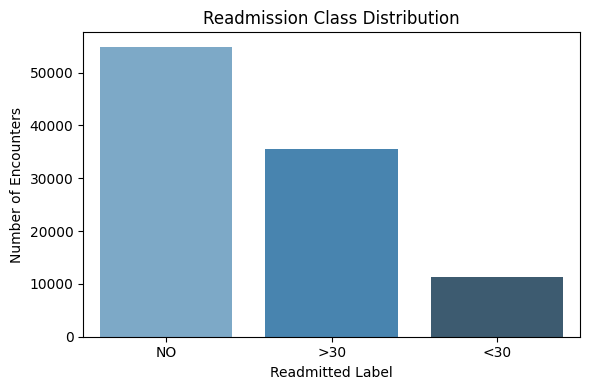

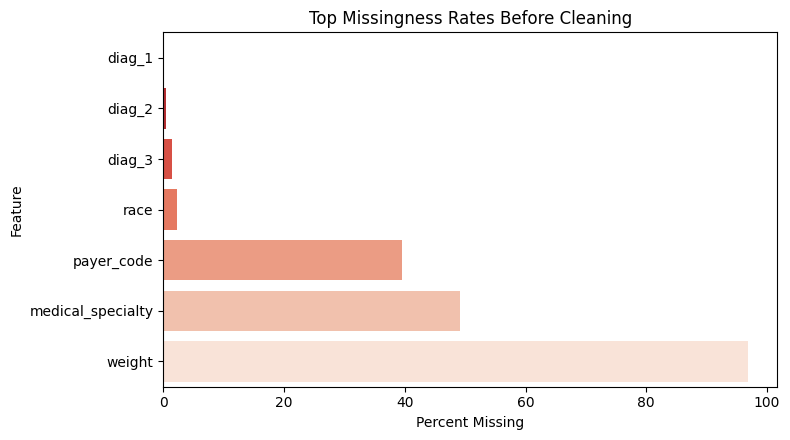

In [20]:
RANDOM_STATE = 178
PREPROCESSING_NOTEBOOK = Path('preprocessing.ipynb')

preprocess_nb = json.loads(PREPROCESSING_NOTEBOOK.read_text())
preprocess_namespace = {}

for cell in preprocess_nb['cells']:
    if cell['cell_type'] == 'code':
        exec(''.join(cell['source']), preprocess_namespace)

X_train = preprocess_namespace['X_train']
X_val = preprocess_namespace['X_val']
X_test = preprocess_namespace['X_test']
y_train_raw = preprocess_namespace['y_train_raw']
y_val_raw = preprocess_namespace['y_val_raw']
y_test_raw = preprocess_namespace['y_test_raw']
y_train = preprocess_namespace['y_train']
y_val = preprocess_namespace['y_val']
y_test = preprocess_namespace['y_test']
label_encoder = preprocess_namespace['label_encoder']
train_raw = preprocess_namespace['train_raw']
val_raw = preprocess_namespace['val_raw']
test_raw = preprocess_namespace['test_raw']
train_groups = train_raw['patient_nbr']
TARGET = preprocess_namespace['TARGET']
clean_split = preprocess_namespace['clean_split']

X_train_prepared = preprocess_namespace['X_train_prepared']
X_val_prepared = preprocess_namespace['X_val_prepared']
X_test_prepared = preprocess_namespace['X_test_prepared']

if hasattr(X_train_prepared, 'toarray'):
    X_train_prepared = X_train_prepared.toarray()
    X_val_prepared = X_val_prepared.toarray()
    X_test_prepared = X_test_prepared.toarray()

split_summary = pd.DataFrame({
    'split': ['train', 'validation', 'test'],
    'rows': [len(train_raw), len(val_raw), len(test_raw)],
    'unique_patients': [
        train_raw['patient_nbr'].nunique(),
        val_raw['patient_nbr'].nunique(),
        test_raw['patient_nbr'].nunique(),
    ]
})

class_balance_df = pd.concat({
    'count': pd.DataFrame({
        'train': y_train_raw.value_counts().sort_index(),
        'validation': y_val_raw.value_counts().sort_index(),
        'test': y_test_raw.value_counts().sort_index(),
    }),
    'pct': pd.DataFrame({
        'train': y_train_raw.value_counts(normalize=True).sort_index(),
        'validation': y_val_raw.value_counts(normalize=True).sort_index(),
        'test': y_test_raw.value_counts(normalize=True).sort_index(),
    }).round(4),
}, axis=1)

split_summary, class_balance_df, X_train_prepared.shape


In [21]:
mlp = MLPClassifier(
    solver='adam',
    early_stopping=True,
    max_iter=300,
    n_iter_no_change=15,
    random_state=RANDOM_STATE,
)

param_distributions = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],
    'activation': ['relu', 'tanh'],
    'alpha': [1e-5, 1e-4, 1e-3],
    'learning_rate_init': [1e-4, 3e-4, 1e-3],
    'batch_size': [128, 256],
}

search_cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=param_distributions,
    n_iter=12,
    scoring='f1_macro',
    cv=search_cv,
    n_jobs=-1,
    refit=True,
    random_state=RANDOM_STATE,
    verbose=1,
)

search.fit(X_train_prepared, y_train, groups=train_groups)

best_params_df = pd.DataFrame({
    'hyperparameter': list(search.best_params_.keys()),
    'value': list(search.best_params_.values()),
})

cv_results_df = (
    pd.DataFrame(search.cv_results_)
    .sort_values('rank_test_score')
    [[
        'rank_test_score',
        'mean_test_score',
        'std_test_score',
        'param_hidden_layer_sizes',
        'param_activation',
        'param_alpha',
        'param_learning_rate_init',
        'param_batch_size',
    ]]
    .head(5)
    .rename(columns={
        'rank_test_score': 'rank',
        'mean_test_score': 'mean_macro_f1',
        'std_test_score': 'std_macro_f1',
        'param_hidden_layer_sizes': 'hidden_layer_sizes',
        'param_activation': 'activation',
        'param_alpha': 'alpha',
        'param_learning_rate_init': 'learning_rate_init',
        'param_batch_size': 'batch_size',
    })
)

display(best_params_df)
cv_results_df


Fitting 4 folds for each of 12 candidates, totalling 48 fits


,hyperparameter,value
0,learning_rate_init,0.001
1,hidden_layer_sizes,"(128,)"
2,batch_size,128
3,alpha,0.001
4,activation,relu


,rank,mean_macro_f1,std_macro_f1,hidden_layer_sizes,activation,alpha,learning_rate_init,batch_size
1,1,0.406962,0.003223,"(128,)",relu,0.00100,0.0010,128
6,2,0.403256,0.007200,"(64, 32)",tanh,0.00001,0.0010,128
10,3,0.402314,0.002471,"(64, 32)",tanh,0.00001,0.0003,128
9,4,0.402138,0.012217,"(128,)",relu,0.00100,0.0003,128
2,5,0.399277,0.005603,"(64, 32)",tanh,0.00100,0.0010,256


In [22]:
best_model = search.best_estimator_

train_pred = best_model.predict(X_train_prepared)
val_pred = best_model.predict(X_val_prepared)
train_pred_labels = label_encoder.inverse_transform(train_pred)
val_pred_labels = label_encoder.inverse_transform(val_pred)

train_val_metrics = pd.DataFrame({
    'train': {
        'accuracy': accuracy_score(y_train, train_pred),
        'macro_f1': f1_score(y_train, train_pred, average='macro'),
        'weighted_f1': f1_score(y_train, train_pred, average='weighted'),
    },
    'validation': {
        'accuracy': accuracy_score(y_val, val_pred),
        'macro_f1': f1_score(y_val, val_pred, average='macro'),
        'weighted_f1': f1_score(y_val, val_pred, average='weighted'),
    },
}).round(4)

train_val_metrics


,train,validation
accuracy,0.5926,0.5783
macro_f1,0.4084,0.3924
weighted_f1,0.5407,0.5254


,epoch,training_loss
15,16,0.801662
16,17,0.795895
17,18,0.792350
18,19,0.787674
19,20,0.783478


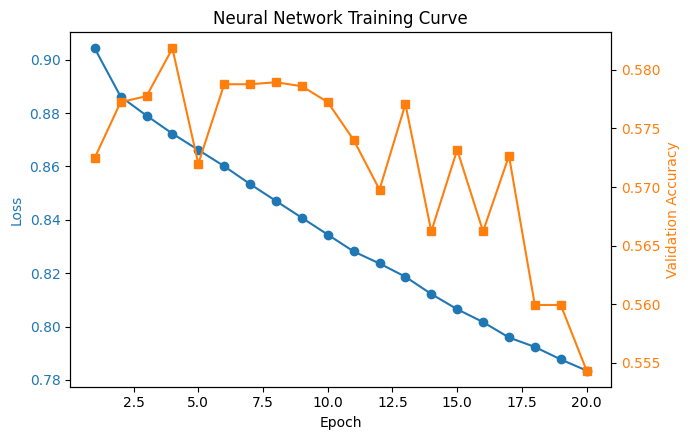

In [23]:
training_curve = pd.DataFrame({
    'epoch': range(1, len(best_model.loss_curve_) + 1),
    'training_loss': best_model.loss_curve_,
})

if hasattr(best_model, 'validation_scores_') and best_model.validation_scores_ is not None:
    validation_curve = pd.DataFrame({
        'epoch': range(1, len(best_model.validation_scores_) + 1),
        'validation_accuracy': best_model.validation_scores_,
    })
else:
    validation_curve = None

fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax1.plot(training_curve['epoch'], training_curve['training_loss'], color='tab:blue', marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

if validation_curve is not None:
    ax2 = ax1.twinx()
    ax2.plot(validation_curve['epoch'], validation_curve['validation_accuracy'], color='tab:orange', marker='s')
    ax2.set_ylabel('Validation Accuracy', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

ax1.set_title('Neural Network Training Curve')
fig.tight_layout()
training_curve.tail()


In [24]:
print(classification_report(y_val_raw, val_pred_labels, zero_division=0))


              precision    recall  f1-score   support

         <30       0.45      0.04      0.07      2289
         >30       0.52      0.33      0.40      7264
          NO       0.60      0.86      0.71     10716

    accuracy                           0.58     20269
   macro avg       0.52      0.41      0.39     20269
weighted avg       0.55      0.58      0.53     20269



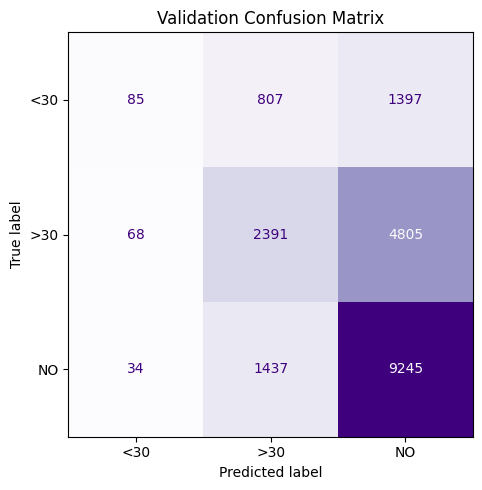

In [25]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val_raw,
    val_pred_labels,
    ax=ax,
    cmap='Purples',
    colorbar=False,
)
ax.set_title('Validation Confusion Matrix')
plt.tight_layout()


## Final Test Evaluation

After hyperparameter selection is finished, refit the chosen network on the combined training and validation data and evaluate once on the held-out test set.


In [26]:
train_val_combined = pd.concat([train_raw, val_raw], ignore_index=True)
combined_specialty_keepers = set(
    train_val_combined['medical_specialty']
    .fillna('Missing')
    .value_counts()
    .loc[lambda s: s >= 500]
    .index
)
combined_constant_cols = [
    col for col in train_val_combined.columns
    if train_val_combined[col].nunique(dropna=False) == 1
]

train_val_df = clean_split(train_val_combined, combined_specialty_keepers, combined_constant_cols)
final_test_df = clean_split(test_raw, combined_specialty_keepers, combined_constant_cols)

X_train_val = train_val_df.drop(columns=[TARGET])
y_train_val_raw = train_val_df[TARGET]
X_test_final = final_test_df.drop(columns=[TARGET])
y_test_final_raw = final_test_df[TARGET]

y_train_val = label_encoder.fit_transform(y_train_val_raw)
y_test_final = label_encoder.transform(y_test_final_raw)

preprocessor = preprocess_namespace['preprocessor']
X_train_val_prepared = preprocessor.fit_transform(X_train_val)
X_test_final_prepared = preprocessor.transform(X_test_final)

if hasattr(X_train_val_prepared, 'toarray'):
    X_train_val_prepared = X_train_val_prepared.toarray()
    X_test_final_prepared = X_test_final_prepared.toarray()

final_model = MLPClassifier(
    solver='adam',
    early_stopping=True,
    max_iter=300,
    n_iter_no_change=15,
    random_state=RANDOM_STATE,
    hidden_layer_sizes=search.best_params_['hidden_layer_sizes'],
    activation=search.best_params_['activation'],
    alpha=search.best_params_['alpha'],
    learning_rate_init=search.best_params_['learning_rate_init'],
    batch_size=search.best_params_['batch_size'],
)

final_model.fit(X_train_val_prepared, y_train_val)
test_pred = final_model.predict(X_test_final_prepared)
test_pred_labels = label_encoder.inverse_transform(test_pred)

test_metrics = pd.Series({
    'accuracy': accuracy_score(y_test_final, test_pred),
    'macro_f1': f1_score(y_test_final, test_pred, average='macro'),
    'weighted_f1': f1_score(y_test_final, test_pred, average='weighted'),
})

validation_vs_test = pd.DataFrame({
    'validation': train_val_metrics['validation'],
    'test': test_metrics,
}).round(4)

display(test_metrics.round(4))
validation_vs_test


accuracy       0.5831
macro_f1       0.3921
weighted_f1    0.5303
dtype: float64

,validation,test
accuracy,0.5783,0.5831
macro_f1,0.3924,0.3921
weighted_f1,0.5254,0.5303


,validation,test
accuracy,0.5783,0.5831
macro_f1,0.3924,0.3921
weighted_f1,0.5254,0.5303


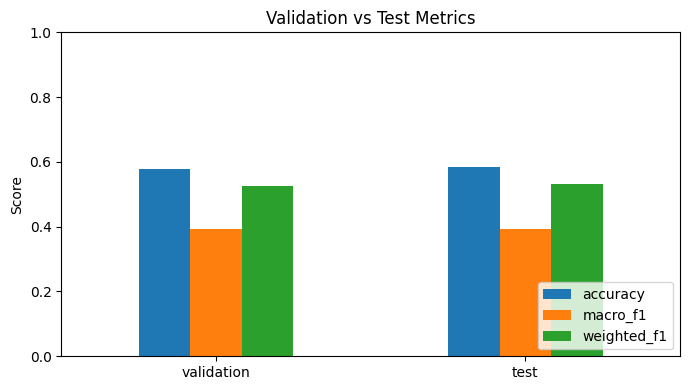

In [27]:
fig, ax = plt.subplots(figsize=(7, 4))
validation_vs_test.T.plot(kind='bar', ax=ax)
ax.set_title('Validation vs Test Metrics')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
validation_vs_test


In [28]:
test_report_df = pd.DataFrame(classification_report(
    y_test_final_raw,
    test_pred_labels,
    zero_division=0,
    output_dict=True,
)).T

test_report_df.round(4)


,precision,recall,f1-score,support
<30,0.5082,0.0273,0.0518,2273.0000
>30,0.5266,0.3450,0.4169,7185.0000
NO,0.6010,0.8605,0.7077,10722.0000
accuracy,0.5831,0.5831,0.5831,0.5831
macro avg,0.5453,0.4109,0.3921,20180.0000
weighted avg,0.5641,0.5831,0.5303,20180.0000


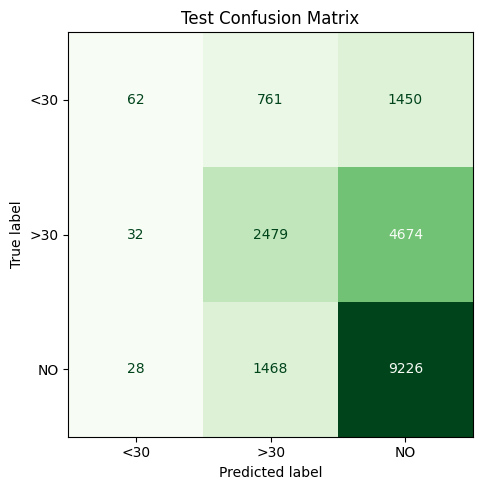

In [29]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_final_raw,
    test_pred_labels,
    ax=ax,
    cmap='Greens',
    colorbar=False,
)
ax.set_title('Test Confusion Matrix')
plt.tight_layout()


,recall,f1-score
<30,0.0273,0.0518
>30,0.3450,0.4169
NO,0.8605,0.7077


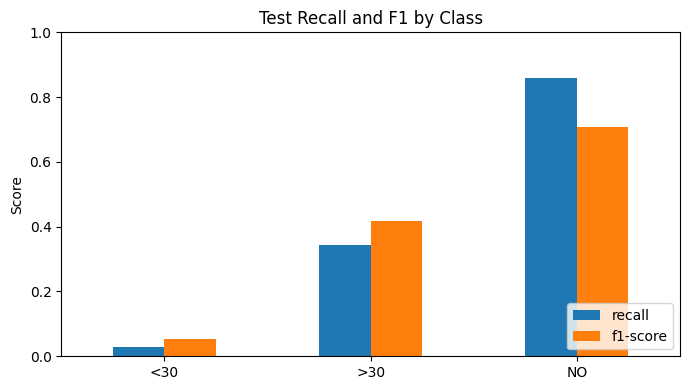

In [30]:
per_class_test = test_report_df.loc[['<30', '>30', 'NO'], ['recall', 'f1-score']].round(4)

fig, ax = plt.subplots(figsize=(7, 4))
per_class_test.plot(kind='bar', ax=ax)
ax.set_title('Test Recall and F1 by Class')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
per_class_test
